# Marker Repo - annotation zebrahub using homology

This example shows the application of the homology functions of the Marker Repo by annotating and comparing already annotated data from Zebrahub with the transferred data from PanglaoDB.

## Loading packages

In [1]:
import markerrepo.marker_repo as mr
import markerrepo.wrappers as wrap
import markerrepo.annotation as annot
import scanpy as sc

%load_ext autoreload
%autoreload 2

## Settings

Specify path of the cloned repository and the h5ad file which is going to be annotated.

In [2]:
repo_path = "/mnt/workspace/mkessle/projects/annotate_by_marker_and_features"
h5ad_path = "/mnt/workspace/mkessle/master/refdata/zf_atlas_10dpf_v4_release.h5ad"

Load anndata

In [3]:
adata = sc.read_h5ad(h5ad_path)

List all possible settings.

In [4]:
annot.list_possible_settings(repo_path, adata)

Possible Settings:
----------------------------------------
1. Possible Organisms or Taxon IDs:
  - human 9606
  - mouse 10090
  - zebrafish 7955
  - rat 10114
  - pig 9823
  - medaka 8090
  - chicken 9031
  - drosophila 7215
  - yeast 4932

2. Available Columns in adata.obs:
  - n_genes
  - n_counts
  - fish
  - timepoint_cluster
  - n_genes_by_counts
  - total_counts
  - total_counts_mt
  - pct_counts_mt
  - total_counts_nc
  - pct_counts_nc
  - zebrafish_anatomy_ontology_class
  - zebrafish_anatomy_ontology_id
  - developmental_stage
  - timepoint

3. Available Columns in adata.var:
  - gene_ids
  - feature_types
  - genome
  - mt
  - nc
  - n_cells_by_counts
  - mean_counts
  - pct_dropout_by_counts
  - total_counts
  - n_cells

4. Available Columns to Search in Marker Repository:
  - List name
  - Marker type
  - Organism name
  - Taxonomy ID
  - Submitter name
  - List type
  - Source
  - tags_transferred
  - Tissue
  - Date
  - Email
  - Marker
  - Info
-------------------------

In [5]:
# taxonomy ID or organism name e.g. "human" or 9606
organism = "zebrafish" 
# the column of the .obs table where the ranked genes groups are stored e.g. "rank_genes_groups"
# if no ranking has been performed yet, enter None
rank_genes_column = None
# the column of the .var table where the gene symbols or ensembl IDs or stored
# enter None if the index column of the .var table are already gene symbols or ensembl IDs 
# which you want to use for your annotation
genes_column = "gene_ids"
# the .obs table column of the clustering you want to annotate e.g. "leiden" or "louvain"
column = "zebrafish_anatomy_ontology_class"
# specify wether your index of the .var tables are ensembl IDs (True) or gene symbols (False)
ensembl = True
# specify the marker lists selection you want to use for the annotation
# the column to search in, None to search all columns, e.g. "source", "Organism name", etc.
col_to_search = "Source"
# search terms: "-" exclude keyword, "+" must contain keyword
# separate keywords with  "," e.g. ["+panglao.se", "+mouse"]
search_terms = ["panglao.se"]

Validate input and load anndata object

In [6]:
annot.validate_settings(repo_path, adata, organism, rank_genes_column, genes_column, column, ensembl, col_to_search, search_terms)

Initiating whitelist fetching...
Directory /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/metadata_whitelists already exists.
Update is set to False. Skipping update.
Whitelist fetching process completed.

All settings are valid.
Summary of settings:
----------------------------------------
  Repo path: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features
  Organism: zebrafish
  Rank genes column: None
  Genes column: gene_ids
  Clustering column: zebrafish_anatomy_ontology_class
  Ensembl IDs: True
  Column to search: Source
  Search terms: ['panglao.se']
----------------------------------------


True

## Prepare adata

### Set genes to index, if not already done.

In [7]:
if genes_column:
    adata.var.reset_index(inplace=True)  # remove old index values and save them in the column ['index']
    adata.var.set_index(genes_column, inplace=True)  # set genes as index
    adata.var.index = adata.var.index.astype('str')  # to avoid index being categorical
    adata.var_names_make_unique(join='_')
    
display(adata.var)

,index,feature_types,genome,mt,nc,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,n_cells
gene_ids,,,,,,,,,,
ENSDARG00000102141,ptpn12,Gene Expression,Danio.rerio_genome_Zebrabow_6,False,False,1552,0.013193,98.713858,1592.0,1552
ENSDARG00000102123,phtf2,Gene Expression,Danio.rerio_genome_Zebrabow_6,False,False,195,0.001624,99.838404,196.0,195
ENSDARG00000114503,phtf2-1,Gene Expression,Danio.rerio_genome_Zebrabow_6,False,False,2821,0.024803,97.662239,2993.0,2821
ENSDARG00000115971,CU856344.1,Gene Expression,Danio.rerio_genome_Zebrabow_6,False,False,44,0.000365,99.963537,44.0,44
ENSDARG00000098311,si:zfos-932h1.3,Gene Expression,Danio.rerio_genome_Zebrabow_6,False,False,2299,0.019864,98.094820,2397.0,2299
...,...,...,...,...,...,...,...,...,...,...
ENSDARG00000083462,NC_002333.22,Gene Expression,Danio.rerio_genome_Zebrabow_6,False,True,943,0.008047,99.218536,971.0,943
ENSDARG00000081475,NC_002333.11,Gene Expression,Danio.rerio_genome_Zebrabow_6,False,True,343,0.002859,99.715756,345.0,343
dTomato,dTomato,Gene Expression,Danio.rerio_genome_Zebrabow_6,False,False,4,0.000033,99.996685,4.0,4


## Prepare annotation

### Ranking

Rank genes, if not already done.

In [8]:
if not rank_genes_column:
    rank_genes_column = f'rank_genes_groups_{column}'
    print(f'Ranking genes groups for clusters using obs column {column}')
    sc.tl.rank_genes_groups(adata, groupby=f'{column}', use_raw=False, key_added=rank_genes_column)

Ranking genes groups for clusters using obs column zebrafish_anatomy_ontology_class


/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:394: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'scores'] = scores[global_indices]
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:399

/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:409: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'pvals_adj'] = pvals_adj[global_indices]
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:420: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:394: Perfo

/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:409: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'pvals_adj'] = pvals_adj[global_indices]
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:420: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:394: Perfo

## Create suitable marker list(s)

The paths of the marker lists will be stored in the <b>marker_lists</b> variable. They will work as input for the actual cell type annotation of the next cell. If the index of adata.var contains ensembl IDs, set <b>ensembl=True</b>, otherwise gene symbols are used.

Trying to create marker lists via homology...
Initiating whitelist fetching...
Directory ./metadata_whitelists already exists.
Update is set to False. Skipping update.
Whitelist fetching process completed.

Loading genes of zebrafish...
Done!


The following source organisms can be used in both approaches: mouse 10090, human 9606.

Starting HomoloGene approach...
Loading genes of mouse...
Done!

Get HomoloGene db...

DataFrame of the markers of the source organism (mouse) to be transferred to the target organism (zebrafish):


,Marker,Info
0,SLC26A4 ENSMUSG00000020651,Chromaffin cells
1,AGRP ENSMUSG00000005705,Chromaffin cells
2,IGF2 ENSMUSG00000048583,Chromaffin cells
3,SNAP25 ENSMUSG00000027273,Chromaffin cells
4,SLC18A2 ENSMUSG00000025094,Chromaffin cells
...,...,...
8079,PIWIL2 ENSMUSG00000033644,Embryonic stem cells
8080,PIWIL4 ENSMUSG00000036912,Embryonic stem cells
8081,LIFR ENSMUSG00000054263,Embryonic stem cells
8082,IL6ST ENSMUSG00000021756,Embryonic stem cells


Filter source DataFrame by the number of target genes per source gene: remove all source genes that lead to more than 1 target genes.

The Marker Transfer Rate is 79.21%, indicating the percentage of successfully transferred markers from the source to the target organism.

General information:
Percentage of genes that can potentially be transferred from the source organism: 25.35%
If all genes from the source organism were transferred, they would cover 32.30% of all genes of the target organism.

Count of target genes per source gene:


,Source Gene,Count target genes
185,AA987161,655
12048,ZFP738 ENSMUSG00000048280,655
179,A530054K11RIK,655
7526,PCDHB3 ENSMUSG00000045498,63
7301,OLFR935 ENSMUSG00000059595,25
...,...,...
4325,GMIP ENSMUSG00000036246,1
4326,GMNC ENSMUSG00000068428,1
4327,GMNN ENSMUSG00000006715,1
4328,GMPPA ENSMUSG00000033021,1


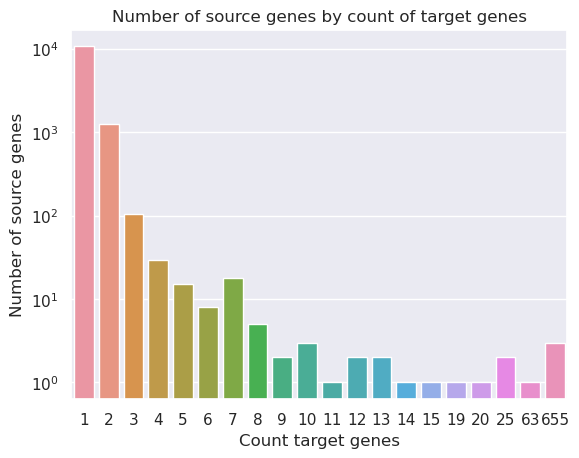

Filtered source DataFrame with target_counts <= 1:


,Marker,Info
0,SLC26A4 ENSMUSG00000020651,Chromaffin cells
1,SLC26A4 ENSMUSG00000020651,Platelets
2,SLC26A4 ENSMUSG00000020651,Intercalated cells
3,SLC26A4 ENSMUSG00000020651,Transient cells
4,SNAP25 ENSMUSG00000027273,Chromaffin cells
...,...,...
4136,HMGA2 ENSMUSG00000056758,Embryonic stem cells
4137,NACC1 ENSMUSG00000001910,Embryonic stem cells
4138,GDF3 ENSMUSG00000030117,Embryonic stem cells
4139,SMAD2 ENSMUSG00000024563,Embryonic stem cells


Filtered: 3943 source genes, 48.78%

Create DataFrame containing the transferred genes based on the filter criteria.

The Marker Transfer Rate is 99.90%, indicating the percentage of successfully transferred markers from the source to the target organism.

Transferred markers:


,Marker,Info
0,SLC26A4 ENSDARG00000069431,Chromaffin cells
1,SLC26A4 ENSDARG00000069431,Platelets
2,SLC26A4 ENSDARG00000069431,Intercalated cells
3,SLC26A4 ENSDARG00000069431,Transient cells
4,SNAP25A ENSDARG00000020609,Chromaffin cells
...,...,...
4136,HMGA2 ENSDARG00000069912,Embryonic stem cells
4137,LOC572093,Embryonic stem cells
4138,DVR1,Embryonic stem cells
4139,SMAD2 ENSDARG00000006389,Embryonic stem cells


Weighted transferred markers:


,Marker,Info,Score
4140,PIWIL1 ENSDARG00000041699,Embryonic stem cells,0.0
2952,DNTT ENSDARG00000104792,B cells,0.0
2955,EDEM1 ENSDARG00000025094,B cells,0.0
2956,CRELD2 ENSDARG00000029071,B cells,0.0
1183,CUL5B ENSDARG00000004260,Immature neurons,0.0
...,...,...,...
1237,ISL1 ENSDARG00000004023,Neurons,1.0
1236,ISL1 ENSDARG00000004023,Neuroblasts,1.0
1235,ISL1 ENSDARG00000004023,Motor neurons,1.0
1242,ISL1 ENSDARG00000004023,Beta cells,1.0


Folder /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers created.
Marker list saved: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/mouse_zebrafish_HomoloGene_annotation
Loading genes of human...
Done!

Get HomoloGene db...

DataFrame of the markers of the source organism (human) to be transferred to the target organism (zebrafish):


,Marker,Info
0,SLC26A4 ENSG00000091137,Chromaffin cells
1,AGRP ENSG00000159723,Chromaffin cells
2,IGF2 ENSG00000167244,Chromaffin cells
3,SNAP25 ENSG00000132639,Chromaffin cells
4,SLC18A2 ENSG00000165646,Chromaffin cells
...,...,...
8045,PIWIL1 ENSG00000125207,Embryonic stem cells
8046,PIWIL2 ENSG00000197181,Embryonic stem cells
8047,PIWIL4 ENSG00000134627,Embryonic stem cells
8048,LIFR ENSG00000113594,Embryonic stem cells


Filter source DataFrame by the number of target genes per source gene: remove all source genes that lead to more than 1 target genes.

The Marker Transfer Rate is 79.43%, indicating the percentage of successfully transferred markers from the source to the target organism.

General information:
Percentage of genes that can potentially be transferred from the source organism: 23.07%
If all genes from the source organism were transferred, they would cover 31.58% of all genes of the target organism.

Count of target genes per source gene:


,Source Gene,Count target genes
12026,ZNF729 ENSG00000196350,655
7444,PCDHB3 ENSG00000113205,63
7442,PCDHA8 ENSG00000204962,40
4651,HIST2H2BE,31
7237,OR8G5 ENSG00000255298,25
...,...,...
4293,GPR142 ENSG00000257008,1
4294,GPR143 ENSG00000101850,1
4295,GPR144,1
4296,GPR146 ENSG00000164849,1


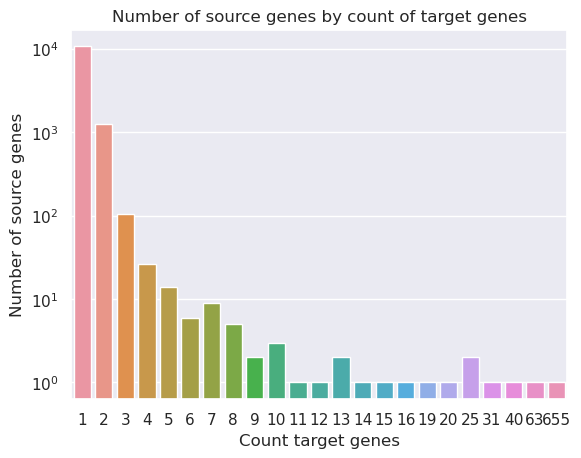

Filtered source DataFrame with target_counts <= 1:


,Marker,Info
0,SLC26A4 ENSG00000091137,Chromaffin cells
1,SLC26A4 ENSG00000091137,Platelets
2,SLC26A4 ENSG00000091137,Intercalated cells
3,SLC26A4 ENSG00000091137,Transient cells
4,SNAP25 ENSG00000132639,Chromaffin cells
...,...,...
4116,TAF8 ENSG00000137413,Embryonic stem cells
4117,NACC1 ENSG00000160877,Embryonic stem cells
4118,GDF3 ENSG00000184344,Embryonic stem cells
4119,SMAD2 ENSG00000175387,Embryonic stem cells


Filtered: 3929 source genes, 48.81%

Create DataFrame containing the transferred genes based on the filter criteria.

The Marker Transfer Rate is 100.00%, indicating the percentage of successfully transferred markers from the source to the target organism.

Transferred markers:


,Marker,Info
0,SLC26A4 ENSDARG00000069431,Chromaffin cells
1,SLC26A4 ENSDARG00000069431,Platelets
2,SLC26A4 ENSDARG00000069431,Intercalated cells
3,SLC26A4 ENSDARG00000069431,Transient cells
4,SNAP25A ENSDARG00000020609,Chromaffin cells
...,...,...
4116,TAF8 ENSDARG00000026806,Embryonic stem cells
4117,LOC572093,Embryonic stem cells
4118,DVR1,Embryonic stem cells
4119,SMAD2 ENSDARG00000006389,Embryonic stem cells


Weighted transferred markers:


,Marker,Info,Score
4120,PIWIL1 ENSDARG00000041699,Embryonic stem cells,0.0
2938,CRELD2 ENSDARG00000029071,B cells,0.0
2941,EDEM2 ENSDARG00000028448,B cells,0.0
1178,CUL5B ENSDARG00000004260,Immature neurons,0.0
1177,STIM2B ENSDARG00000001776,Immature neurons,0.0
...,...,...,...
1229,ISL1 ENSDARG00000004023,Interneurons,1.0
1241,ISL1 ENSDARG00000004023,Satellite cells,1.0
1240,ISL1 ENSDARG00000004023,Pancreatic progenitor cells,1.0
1236,ISL1 ENSDARG00000004023,Cardiac stem and precursor cells,1.0


Marker list saved: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/human_zebrafish_HomoloGene_annotation

Starting BioMart approach...

Specify BioMart target organism selection:
Selection: drerio


Specify BioMart source organism selection:
Default organism: mmusculus
Loading genes of mouse...
Done!

Fetch necessary data from BioMart...

DataFrame of the markers of the source organism (mouse) to be transferred to the target organism (zebrafish):


,Marker,Info
0,SLC26A4 ENSMUSG00000020651,Chromaffin cells
1,AGRP ENSMUSG00000005705,Chromaffin cells
2,IGF2 ENSMUSG00000048583,Chromaffin cells
3,SNAP25 ENSMUSG00000027273,Chromaffin cells
4,SLC18A2 ENSMUSG00000025094,Chromaffin cells
...,...,...
8079,PIWIL2 ENSMUSG00000033644,Embryonic stem cells
8080,PIWIL4 ENSMUSG00000036912,Embryonic stem cells
8081,LIFR ENSMUSG00000054263,Embryonic stem cells
8082,IL6ST ENSMUSG00000021756,Embryonic stem cells


Filter source DataFrame by the number of target genes per source gene: remove all source genes that lead to more than 1 target genes.

The Marker Transfer Rate is 127.68%, indicating the percentage of successfully transferred markers from the source to the target organism.

General information:
Percentage of genes that can potentially be transferred from the source organism: 41.89%
If all genes from the source organism were transferred, they would cover 71.67% of all genes of the target organism.

Count of target genes per source gene:


,Source Gene,Count target genes
3227,TRAC ENSMUSG00000076928,37
1700,CD22 ENSMUSG00000030577,35
3226,TRDV1 ENSMUSG00000076864,32
3139,HTRA2 ENSMUSG00000068329,25
999,MS4A7 ENSMUSG00000024672,24
...,...,...
1329,SNX16 ENSMUSG00000027534,1
1330,NFATC2 ENSMUSG00000027544,1
1331,SALL4 ENSMUSG00000027547,1
1335,COL9A3 ENSMUSG00000027570,1


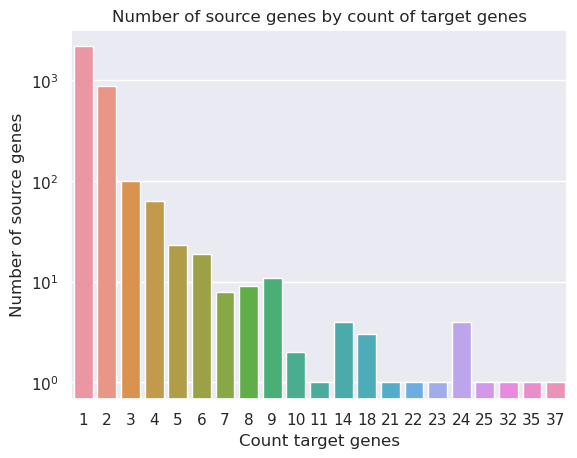

Filtered source DataFrame with target_counts <= 1:


,Marker,Info
0,SLC26A4 ENSMUSG00000020651,Chromaffin cells
1,SLC26A4 ENSMUSG00000020651,Platelets
2,SLC26A4 ENSMUSG00000020651,Intercalated cells
3,SLC26A4 ENSMUSG00000020651,Transient cells
4,AGRP ENSMUSG00000005705,Chromaffin cells
...,...,...
3735,TAF8 ENSMUSG00000023980,Embryonic stem cells
3736,HMGA2 ENSMUSG00000056758,Embryonic stem cells
3737,ESRRB ENSMUSG00000021255,Embryonic stem cells
3738,PIWIL1 ENSMUSG00000029423,Embryonic stem cells


Filtered: 4344 source genes, 53.74%

Create DataFrame containing the transferred genes based on the filter criteria.

The Marker Transfer Rate is 100.00%, indicating the percentage of successfully transferred markers from the source to the target organism.

Transferred markers:


,Marker,Info
0,CDH2 ENSDARG00000018693,Hematopoietic stem cells
1,HGD ENSDARG00000058005,Proximal tubule cells
2,DSC2L ENSDARG00000039677,Keratinocytes
5,SI:CH73-74H11.1 ENSDARG00000062750,Trichocytes
6,LMNB1 ENSDARG00000044299,Erythroblasts
...,...,...
3735,EHF ENSDARG00000052115,Delta cells
3736,EHF ENSDARG00000052115,Langerhans cells
3737,SPRED1 ENSDARG00000041449,Mast cells
3738,LRRC57 ENSDARG00000043938,Germ cells


Weighted transferred markers:


,Marker,Info,Score
0,CDH2 ENSDARG00000018693,Hematopoietic stem cells,0.0
1868,SLC7A7 ENSDARG00000055226,Macrophages,0.0
1865,RAB30 ENSDARG00000037884,Dendritic cells,0.0
3738,LRRC57 ENSDARG00000043938,Germ cells,0.0
1861,CADPS2 ENSDARG00000013312,Dopaminergic neurons,0.0
...,...,...,...
163,SI:DKEY-30C15.12 ENSDARG00000058546,Mammary epithelial cells,1.0
164,SI:DKEY-30C15.12 ENSDARG00000058546,Satellite cells,1.0
166,SI:DKEY-30C15.12 ENSDARG00000058546,Embryonic stem cells,1.0
158,SI:DKEY-30C15.12 ENSDARG00000058546,Plasmacytoid dendritic cells,1.0


Marker list saved: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/mouse_zebrafish_BioMart_annotation

Specify BioMart source organism selection:
Selection: hsapiens

Loading genes of human...
Done!

Fetch necessary data from BioMart...

DataFrame of the markers of the source organism (human) to be transferred to the target organism (zebrafish):


,Marker,Info
0,SLC26A4 ENSG00000091137,Chromaffin cells
1,AGRP ENSG00000159723,Chromaffin cells
2,IGF2 ENSG00000167244,Chromaffin cells
3,SNAP25 ENSG00000132639,Chromaffin cells
4,SLC18A2 ENSG00000165646,Chromaffin cells
...,...,...
8045,PIWIL1 ENSG00000125207,Embryonic stem cells
8046,PIWIL2 ENSG00000197181,Embryonic stem cells
8047,PIWIL4 ENSG00000134627,Embryonic stem cells
8048,LIFR ENSG00000113594,Embryonic stem cells


Filter source DataFrame by the number of target genes per source gene: remove all source genes that lead to more than 1 target genes.

The Marker Transfer Rate is 130.17%, indicating the percentage of successfully transferred markers from the source to the target organism.

General information:
Percentage of genes that can potentially be transferred from the source organism: 35.96%
If all genes from the source organism were transferred, they would cover 67.35% of all genes of the target organism.

Count of target genes per source gene:


,Source Gene,Count target genes
76,CD22 ENSG00000012124,35
922,HTRA2 ENSG00000115317,25
770,MS4A6A ENSG00000110077,24
2379,MS4A7 ENSG00000166927,24
2380,MS4A5 ENSG00000166930,24
...,...,...
1309,MNX1 ENSG00000130675,1
1310,GATA5 ENSG00000130700,1
1311,LAMA5 ENSG00000130702,1
1312,ASS1 ENSG00000130707,1


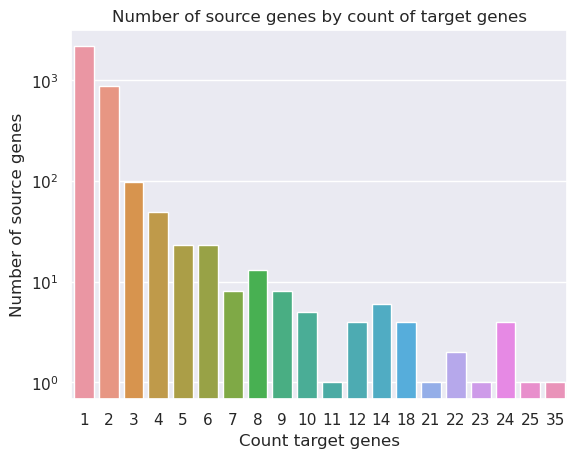

Filtered source DataFrame with target_counts <= 1:


,Marker,Info
0,SLC26A4 ENSG00000091137,Chromaffin cells
1,SLC26A4 ENSG00000091137,Platelets
2,SLC26A4 ENSG00000091137,Intercalated cells
3,SLC26A4 ENSG00000091137,Transient cells
4,AGRP ENSG00000159723,Chromaffin cells
...,...,...
3709,LMNA ENSG00000160789,Embryonic stem cells
3710,TAF8 ENSG00000137413,Embryonic stem cells
3711,HMGA2 ENSG00000149948,Embryonic stem cells
3712,ESRRB ENSG00000119715,Embryonic stem cells


Filtered: 4336 source genes, 53.86%

Create DataFrame containing the transferred genes based on the filter criteria.

The Marker Transfer Rate is 100.00%, indicating the percentage of successfully transferred markers from the source to the target organism.

Transferred markers:


,Marker,Info
0,CRYL1 ENSDARG00000003675,Proximal tubule cells
1,CLDN17 ENSDARG00000099950,Distal tubule cells
2,CLDN17 ENSDARG00000099950,Loop of Henle cells
3,CBY1 ENSDARG00000077409,Germ cells
4,POU4F1 ENSDARG00000005559,Retinal ganglion cells
...,...,...
3709,RYR2B ENSDARG00000003706,Neurons
3710,RYR2B ENSDARG00000003706,Cardiomyocytes
3711,CSF3R ENSDARG00000045959,Microglia
3712,CSF3R ENSDARG00000045959,Monocytes


Weighted transferred markers:


,Marker,Info,Score
0,CRYL1 ENSDARG00000003675,Proximal tubule cells,0.0
2506,TMEM53 ENSDARG00000038789,Germ cells,0.0
1078,KLHL2 ENSDARG00000061786,Oligodendrocytes,0.0
2510,NOX5 ENSDARG00000079773,Platelets,0.0
2514,KCNQ3 ENSDARG00000060085,Pyramidal cells,0.0
...,...,...,...
1971,SI:DKEY-30C15.12 ENSDARG00000058546,Satellite cells,1.0
1972,SI:DKEY-30C15.12 ENSDARG00000058546,Sebocytes,1.0
1973,SI:DKEY-30C15.12 ENSDARG00000058546,Embryonic stem cells,1.0
1966,SI:DKEY-30C15.12 ENSDARG00000058546,Hepatoblasts,1.0


Marker list saved: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/human_zebrafish_BioMart_annotation

Finished!


In [9]:
organism = mr.update_organism(organism, repo_path)
marker_lists = wrap.create_marker_lists(organism, repo_path=repo_path, 
                                        style="score", file_name="zebrahub", ensembl=ensembl,
                                        col_to_search=col_to_search, search_terms=search_terms, force_homology=True)

## Annotate adata using the created list(s)

Output folder: ./annotation/mouse_zebrafish_HomoloGene_annotation/ranked/output/zebrafish_anatomy_ontology_class/ 
DB file: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/mouse_zebrafish_HomoloGene_annotation 
Cluster folder: ./annotation/mouse_zebrafish_HomoloGene_annotation/ranked/clusters/zebrafish_anatomy_ontology_class/ 
Tissue: all
Created folder: ./annotation/mouse_zebrafish_HomoloGene_annotation/ranked/output/zebrafish_anatomy_ontology_class
Writing ranked cluster file sample.cluster_vasculature (1/45)
Writing ranked cluster file sample.cluster_central nervous system (2/45)
Writing ranked cluster file sample.cluster_pectoral fin (3/45)
Writing ranked cluster file sample.cluster_retinal cone cell (4/45)
Writing ranked cluster file sample.cluster_intestine (5/45)
Writing ranked cluster file sample.cluster_peripheral nervous system (6/45)
Writing ranked cluster file sample.cluster_pharyngeal arch (7/45)
Writing ranked cluster file sam

/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


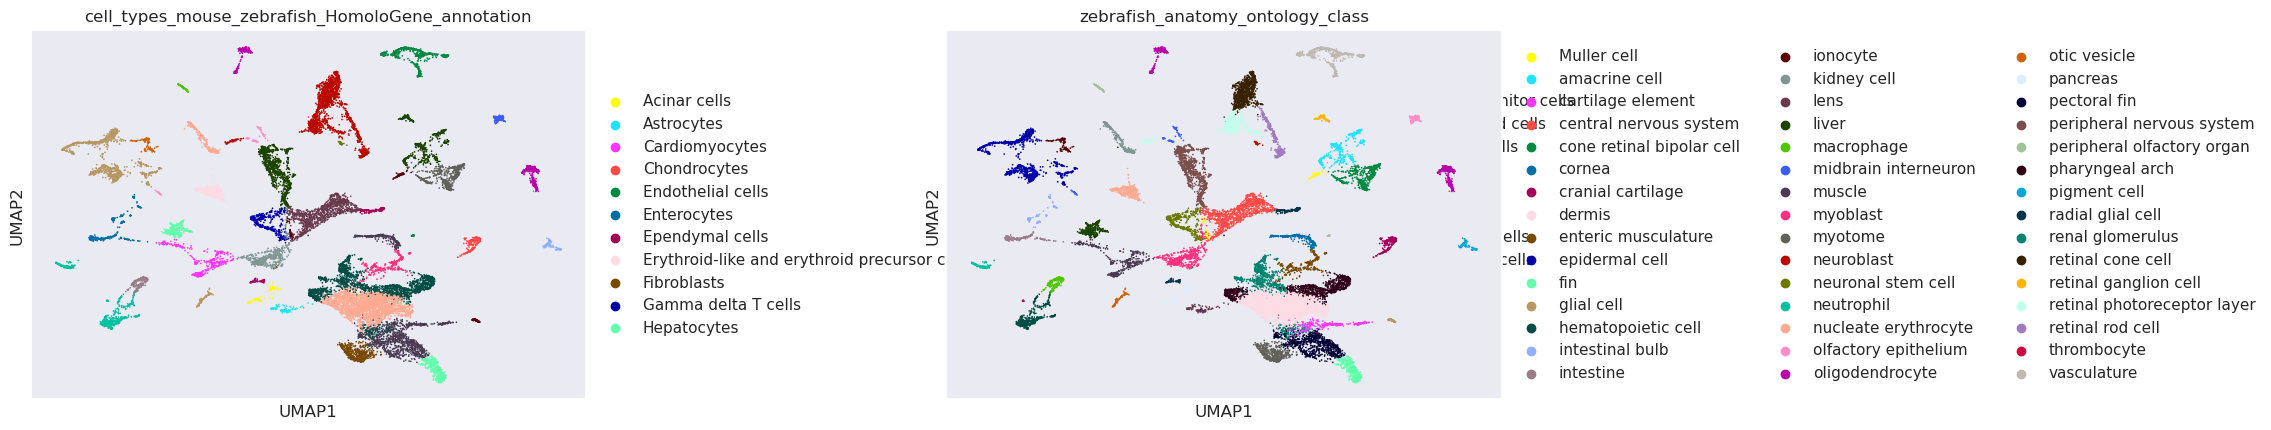

Tables of cell type annotation with clustering zebrafish_anatomy_ontology_class


,Cluster vasculature: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Endothelial cells,1559,57,94,16
1,Endothelial cells (aorta),414,31,53,12
2,Mesangial cells,340,19,41,13
3,Platelets,324,28,68,10
4,Monocytes,316,9,21,16


,Cluster central nervous system: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Neural stem/precursor cells,374,16,37,12
1,Immature neurons,364,11,27,18
2,Neuroendocrine cells,312,5,19,20
3,Luminal epithelial cells,309,8,21,17
4,Oligodendrocytes,297,23,60,19


,Cluster pectoral fin: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Pancreatic progenitor cells,599,6,14,7
1,Proximal tubule cells,497,12,52,17
2,Hepatocytes,329,18,79,19
3,Luminal epithelial cells,317,6,21,17
4,Embryonic stem cells,191,13,42,14


,Cluster retinal cone cell: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Pinealocytes,2027,5,14,9
1,Olfactory epithelial cells,552,26,88,23
2,Germ cells,420,17,54,22
3,Mesangial cells,312,6,41,27
4,Interneurons,300,25,150,17


...

,Cluster otic vesicle: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Keratinocytes,215,6,13,27
1,Chondrocytes,160,12,28,17
2,Luminal epithelial cells,118,12,21,12
3,Müller cells,117,12,32,10
4,Pancreatic progenitor cells,93,7,14,10


,Cluster thrombocyte: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Platelets,293,28,68,12
1,Neural stem/precursor cells,78,5,37,14
2,Erythroblasts,73,5,16,14
3,Germ cells,69,6,54,27
4,Luminal epithelial cells,67,6,21,12


,Cluster Muller cell: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Müller cells,215,14,32,15
1,Transient cells,157,7,16,24
2,Neuroendocrine cells,147,7,19,15
3,Endothelial cells,136,27,94,14
4,Enteric neurons,132,12,39,15


Output folder: ./annotation/human_zebrafish_HomoloGene_annotation/ranked/output/zebrafish_anatomy_ontology_class/ 
DB file: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/human_zebrafish_HomoloGene_annotation 
Cluster folder: ./annotation/human_zebrafish_HomoloGene_annotation/ranked/clusters/zebrafish_anatomy_ontology_class/ 
Tissue: all
Created folder: ./annotation/human_zebrafish_HomoloGene_annotation/ranked/output/zebrafish_anatomy_ontology_class
Writing ranked cluster file sample.cluster_vasculature (1/45)
Writing ranked cluster file sample.cluster_central nervous system (2/45)
Writing ranked cluster file sample.cluster_pectoral fin (3/45)
Writing ranked cluster file sample.cluster_retinal cone cell (4/45)
Writing ranked cluster file sample.cluster_intestine (5/45)
Writing ranked cluster file sample.cluster_peripheral nervous system (6/45)
Writing ranked cluster file sample.cluster_pharyngeal arch (7/45)
Writing ranked cluster file sam

/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


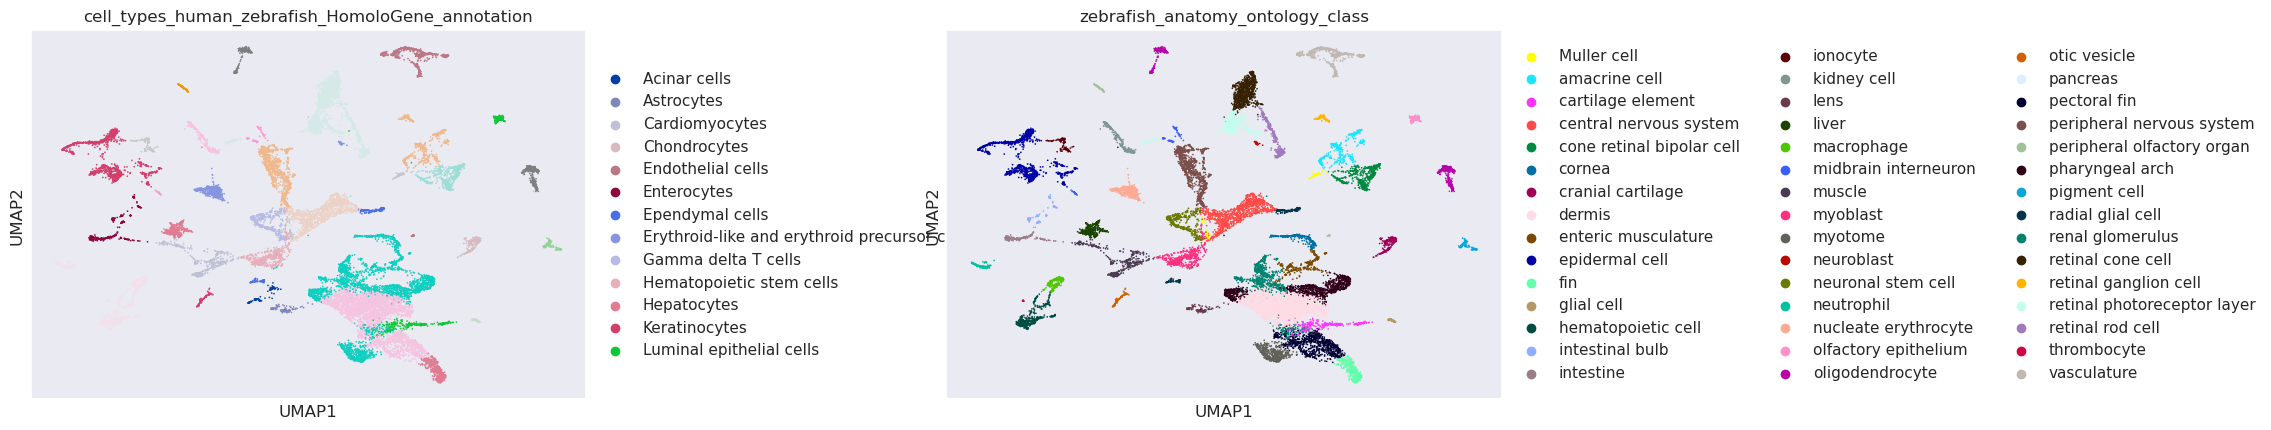

Tables of cell type annotation with clustering zebrafish_anatomy_ontology_class


,Cluster vasculature: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Endothelial cells,1502,56,95,16
1,Endothelial cells (aorta),418,30,52,12
2,Mesangial cells,340,19,41,13
3,Platelets,324,28,68,10
4,Müller cells,315,8,32,14


,Cluster central nervous system: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Neural stem/precursor cells,371,15,37,12
1,Immature neurons,364,11,27,18
2,Luminal epithelial cells,315,7,20,15
3,Neuroendocrine cells,312,5,19,20
4,Basophils,301,14,35,22


,Cluster pectoral fin: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Proximal tubule cells,502,12,51,17
1,Luminal epithelial cells,324,6,20,17
2,Hepatocytes,319,18,84,19
3,Peritubular myoid cells,198,6,18,17
4,Fibroblasts,169,39,101,8


,Cluster retinal cone cell: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Pinealocytes,2103,5,14,14
1,Olfactory epithelial cells,502,25,87,23
2,Germ cells,426,18,53,21
3,Cardiomyocytes,316,13,69,21
4,Mesangial cells,312,6,41,27


...

,Cluster otic vesicle: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Keratinocytes,215,6,13,27
1,Chondrocytes,157,12,29,17
2,Luminal epithelial cells,121,12,20,12
3,Müller cells,118,13,32,9
4,Endothelial cells,92,24,95,15


,Cluster thrombocyte: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Platelets,293,28,68,12
1,Neural stem/precursor cells,78,5,37,14
2,Erythroblasts,73,5,16,14
3,Germ cells,69,6,53,27
4,Luminal epithelial cells,68,6,20,12


,Cluster Muller cell: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Transient cells,157,7,16,24
1,Müller cells,155,13,32,14
2,Neuroendocrine cells,147,7,19,15
3,Endothelial cells,136,27,95,14
4,Enteric neurons,134,12,38,15


Output folder: ./annotation/mouse_zebrafish_BioMart_annotation/ranked/output/zebrafish_anatomy_ontology_class/ 
DB file: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/mouse_zebrafish_BioMart_annotation 
Cluster folder: ./annotation/mouse_zebrafish_BioMart_annotation/ranked/clusters/zebrafish_anatomy_ontology_class/ 
Tissue: all
Created folder: ./annotation/mouse_zebrafish_BioMart_annotation/ranked/output/zebrafish_anatomy_ontology_class
Writing ranked cluster file sample.cluster_vasculature (1/45)
Writing ranked cluster file sample.cluster_central nervous system (2/45)
Writing ranked cluster file sample.cluster_pectoral fin (3/45)
Writing ranked cluster file sample.cluster_retinal cone cell (4/45)
Writing ranked cluster file sample.cluster_intestine (5/45)
Writing ranked cluster file sample.cluster_peripheral nervous system (6/45)
Writing ranked cluster file sample.cluster_pharyngeal arch (7/45)
Writing ranked cluster file sample.cluster_

/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


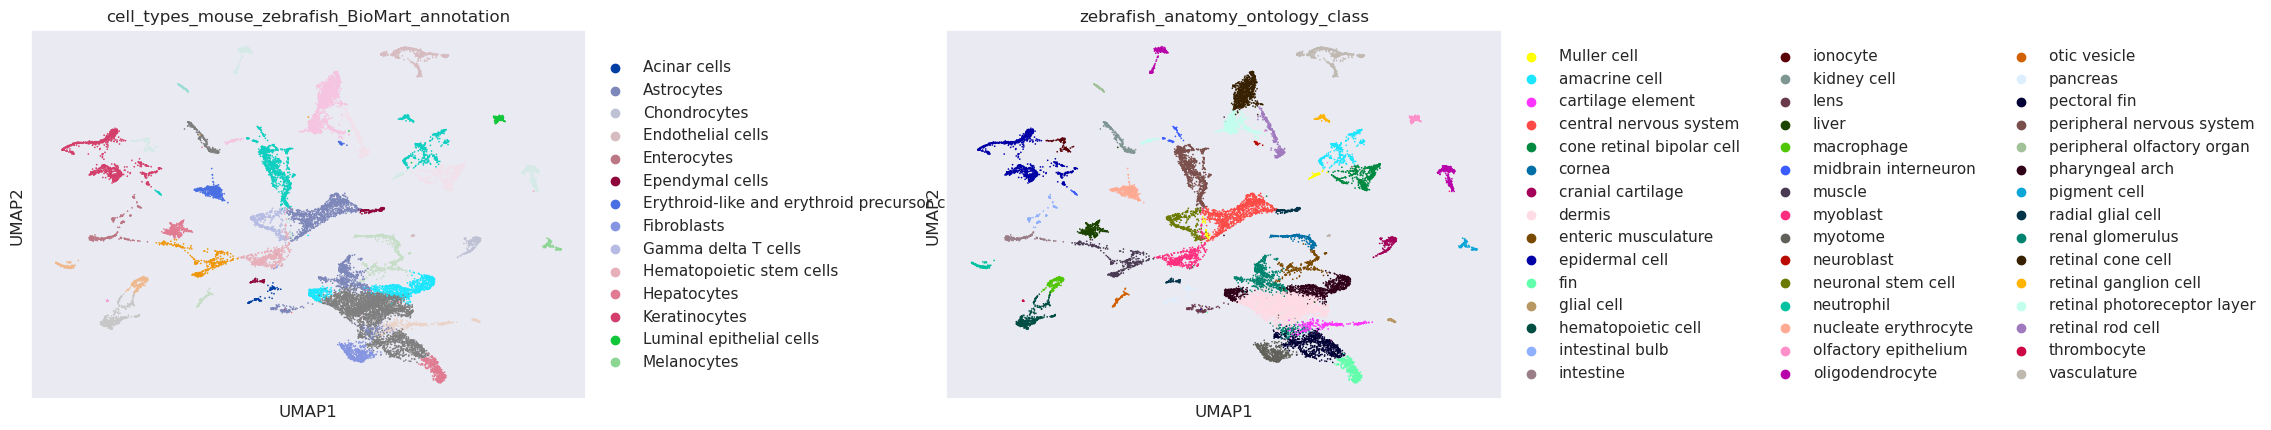

Tables of cell type annotation with clustering zebrafish_anatomy_ontology_class


,Cluster vasculature: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Endothelial cells,1644,65,92,16
1,Endothelial cells (aorta),500,26,48,14
2,Mesangial cells,419,22,35,16
3,Platelets,303,22,59,10
4,Monocytes,287,6,26,23


,Cluster central nervous system: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Astrocytes,420,15,33,15
1,Oligodendrocytes,403,24,49,20
2,Neural stem/precursor cells,391,13,32,14
3,Crypt cells,388,8,9,10
4,Cajal-Retzius cells,329,23,49,18


,Cluster pectoral fin: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Proximal tubule cells,553,12,46,18
1,Hepatocytes,318,14,75,17
2,Luminal epithelial cells,274,6,21,13
3,Endothelial cells (aorta),221,20,48,15
4,Endothelial cells,213,23,92,17


,Cluster retinal cone cell: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Pinealocytes,2098,5,15,14
1,Germ cells,710,23,64,21
2,Olfactory epithelial cells,583,26,81,25
3,Cardiomyocytes,378,13,57,19
4,Sertoli cells,368,12,32,20


...

,Cluster otic vesicle: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Mesangial cells,126,15,35,17
1,Keratinocytes,119,5,10,26
2,Chondrocytes,116,9,23,19
3,Mammary epithelial cells,107,10,16,15
4,Pancreatic progenitor cells,107,6,11,12


,Cluster thrombocyte: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Platelets,242,22,59,11
1,Mesangial cells,136,9,35,22
2,Endothelial cells,98,20,92,15
3,Microglia,90,8,32,17
4,Erythroblasts,75,5,16,15


,Cluster Muller cell: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Oligodendrocytes,221,19,49,21
1,Enteric neurons,139,10,37,18
2,Olfactory epithelial cells,134,30,81,26
3,Mast cells,131,24,66,21
4,Podocytes,131,22,60,15


Output folder: ./annotation/human_zebrafish_BioMart_annotation/ranked/output/zebrafish_anatomy_ontology_class/ 
DB file: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/human_zebrafish_BioMart_annotation 
Cluster folder: ./annotation/human_zebrafish_BioMart_annotation/ranked/clusters/zebrafish_anatomy_ontology_class/ 
Tissue: all
Created folder: ./annotation/human_zebrafish_BioMart_annotation/ranked/output/zebrafish_anatomy_ontology_class
Writing ranked cluster file sample.cluster_vasculature (1/45)
Writing ranked cluster file sample.cluster_central nervous system (2/45)
Writing ranked cluster file sample.cluster_pectoral fin (3/45)
Writing ranked cluster file sample.cluster_retinal cone cell (4/45)
Writing ranked cluster file sample.cluster_intestine (5/45)
Writing ranked cluster file sample.cluster_peripheral nervous system (6/45)
Writing ranked cluster file sample.cluster_pharyngeal arch (7/45)
Writing ranked cluster file sample.cluster_

/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


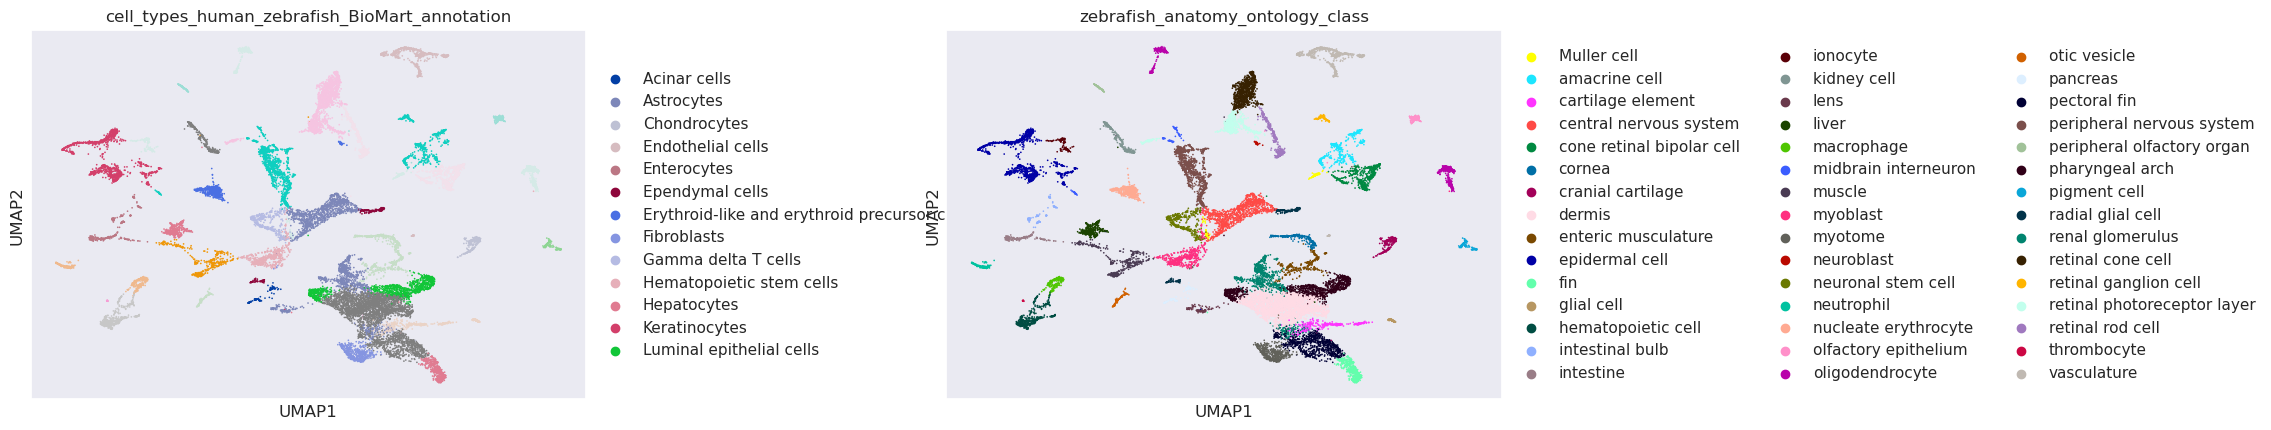

Tables of cell type annotation with clustering zebrafish_anatomy_ontology_class


,Cluster vasculature: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Endothelial cells,1594,64,93,17
1,Endothelial cells (aorta),504,25,47,15
2,Mesangial cells,425,22,34,16
3,Monocytes,323,7,29,24
4,Platelets,306,23,59,11


,Cluster central nervous system: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Astrocytes,414,15,34,15
1,Oligodendrocytes,399,24,50,20
2,Neural stem/precursor cells,398,13,31,14
3,Crypt cells,388,8,9,10
4,Basophils,364,19,36,22


,Cluster pectoral fin: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Proximal tubule cells,553,12,46,18
1,Hepatocytes,318,15,77,18
2,Luminal epithelial cells,267,6,22,13
3,Endothelial cells (aorta),223,19,47,15
4,Endothelial cells,209,22,93,17


,Cluster retinal cone cell: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Pinealocytes,2098,5,15,14
1,Germ cells,756,23,64,21
2,Olfactory epithelial cells,601,26,80,27
3,Erythroid-like and erythroid precursor cells,366,10,43,20
4,Sertoli cells,363,12,33,20


...

,Cluster peripheral olfactory organ: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Olfactory epithelial cells,900,66,80,21
1,Neurons,414,51,112,21
2,Germ cells,407,34,64,24
3,Ependymal cells,328,24,34,20
4,Erythroid-like and erythroid precursor cells,241,23,43,23


,Cluster lens: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Astrocytes,106,10,34,23
1,Hematopoietic stem cells,76,7,42,19
2,Melanocytes,65,5,23,26
3,Podocytes,64,16,59,16
4,Endothelial cells,64,12,93,18


,Cluster otic vesicle: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Mesangial cells,125,14,34,17
1,Keratinocytes,119,5,10,26
2,Pancreatic progenitor cells,107,6,11,12
3,Podocytes,104,30,59,18
4,Mammary epithelial cells,104,10,17,15


,Cluster thrombocyte: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Platelets,242,22,59,11
1,Mesangial cells,138,9,34,22
2,Endothelial cells,97,20,93,15
3,Microglia,89,7,32,19
4,Erythroblasts,75,5,16,15


,Cluster Muller cell: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Oligodendrocytes,219,19,50,21
1,Enteric neurons,140,11,37,16
2,Olfactory epithelial cells,135,30,80,26
3,Neurons,131,41,112,20
4,Mast cells,131,23,66,22


In [10]:
for marker_list in marker_lists:
    name = marker_list.split("/")[-1]
    annotation_dir = f"./annotation/{name}"
    
    # Annotate
    annot.annot_ct(adata, output_path=annotation_dir, db_path=marker_list,
                   cluster_column=f"{column}", rank_genes_column=rank_genes_column, 
                   ct_column=f"cell_types_{name}")
    
    # Plot annotation
    sc.pl.umap(adata, color=[f'cell_types_{name}', f'{column}'], wspace=0.5)

    # Show scores and alternate cell types of eacht cluster
    print(f"Tables of cell type annotation with clustering {column}")
    annot.show_tables(annotation_dir=annotation_dir, n=5, clustering_column=column)

### Compare cell type annotations

In [11]:
compare_df = annot.compare_cell_types(adata, column, marker_lists)

In [12]:
display(compare_df)

,cell_types_mouse_zebrafish_HomoloGene_annotation,cell_types_human_zebrafish_HomoloGene_annotation,cell_types_mouse_zebrafish_BioMart_annotation,cell_types_human_zebrafish_BioMart_annotation
zebrafish_anatomy_ontology_class,,,,
Muller cell,Müller cells,Transient cells,Oligodendrocytes,Oligodendrocytes
amacrine cell,Neurons,Neurons,Neurons,Neurons
cartilage element,Pancreatic progenitor cells,Luminal epithelial cells,Microglia,Microglia
central nervous system,Neural stem/precursor cells,Neural stem/precursor cells,Astrocytes,Astrocytes
cone retinal bipolar cell,Photoreceptor cells,Photoreceptor cells,Photoreceptor cells,Photoreceptor cells
cornea,Pancreatic progenitor cells,Peritubular myoid cells,Mesangial cells,Mesangial cells
cranial cartilage,Chondrocytes,Chondrocytes,Chondrocytes,Chondrocytes
dermis,Proximal tubule cells,Proximal tubule cells,Proximal tubule cells,Proximal tubule cells
enteric musculature,Peritubular myoid cells,Peritubular myoid cells,Mesangial cells,Mesangial cells


### Save plot containing specific cell types

/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


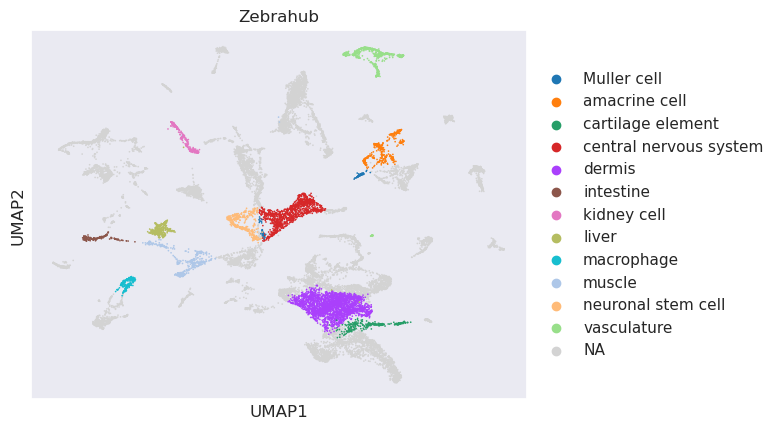

In [13]:
wanted_cell_types = [
    'Muller cell',
    'amacrine cell',
    'central nervous system',
    'cartilage element',
    'liver',
    'kidney cell',
    'macrophage',
    'muscle',
    'neuronal stem cell',
    'intestine',
    'dermis',
    'vasculature'
]

adata.obs['filtered_cell_types'] = [cell_type if cell_type in wanted_cell_types else None for cell_type in adata.obs['zebrafish_anatomy_ontology_class']]
sc.pl.umap(adata, color=['filtered_cell_types'], title='Zebrahub', save="zebrafish_filtered.png")